In [1]:
# ============================================================
# A. Minimal setup for continuing from saved GLM results
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from IPython.display import display

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
DATA_DIR = PROJECT_ROOT / "data"
BIDS_DIR = DATA_DIR / "bids_ackbar"
FMRIPREP_DIR = DATA_DIR / "fmriprep_output"
RAW_MEMORY_PATH = DATA_DIR / "raw" / "final_merged_data.csv"

ANALYSIS_NAME = "memory_quality_post_viewing_parametric"

OUT_DIR = DATA_DIR / "processed" / "glm" / ANALYSIS_NAME
EVENTS_OUT_DIR = OUT_DIR / "events"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
QC_DIR = OUT_DIR / "qc"

POST_SESSION = "ses-05"
POST_TASK = "viewing"
POST_RUN = "01"
BOLD_SPACE = "MNI152NLin2009cAsym"

PRIMARY_CONTRASTS = {
    "all_memory_quality_positive": {
        "old_relevant_memory_quality": 0.5,
        "old_irrelevant_memory_quality": 0.5,
    },
    "relevant_memory_quality_positive": {
        "old_relevant_memory_quality": 1.0,
    },
    "irrelevant_memory_quality_positive": {
        "old_irrelevant_memory_quality": 1.0,
    },
    "relevant_gt_irrelevant_memory_quality": {
        "old_relevant_memory_quality": 1.0,
        "old_irrelevant_memory_quality": -1.0,
    },
}

SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = f"smoothed{int(SMOOTHING_FWHM)}mm"

FIRST_LEVEL_SMOOTHED_DIR = OUT_DIR / f"first_level_{SMOOTHING_LABEL}"
FIRST_LEVEL_SMOOTHED_MAPS_DIR = FIRST_LEVEL_SMOOTHED_DIR / "maps"

SECOND_LEVEL_FROM_SMOOTHED_DIR = OUT_DIR / f"second_level_from_{SMOOTHING_LABEL}"
SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR = SECOND_LEVEL_FROM_SMOOTHED_DIR / "maps"
SECOND_LEVEL_FROM_SMOOTHED_FIG_DIR = FIG_DIR / f"second_level_from_{SMOOTHING_LABEL}"

ROI_DIR = OUT_DIR / "roi"
ROI_MASK_DIR = ROI_DIR / "masks"
ROI_TABLE_DIR = ROI_DIR / "tables"
ROI_FIG_DIR = ROI_DIR / "figures"

for path in [
    OUT_DIR,
    FIG_DIR,
    TABLE_DIR,
    ROI_DIR,
    ROI_MASK_DIR,
    ROI_TABLE_DIR,
    ROI_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("Minimal setup complete.")
print("OUT_DIR:", OUT_DIR)
print("FIRST_LEVEL_SMOOTHED_MAPS_DIR:", FIRST_LEVEL_SMOOTHED_MAPS_DIR)
print("SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR:", SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR)

Minimal setup complete.
OUT_DIR: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric
FIRST_LEVEL_SMOOTHED_MAPS_DIR: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/first_level_smoothed5mm/maps
SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/second_level_from_smoothed5mm/maps


In [3]:
# ============================================================
# B. Recover subject lists and GLM QC tables from saved files
# Robust version: handles different final_analysis_subjects.csv formats
# ============================================================

from IPython.display import display

analysis_subjects_path = TABLE_DIR / "final_analysis_subjects.csv"
first_level_smoothed_qc_path = TABLE_DIR / f"first_level_primary_glm_{SMOOTHING_LABEL}_qc.csv"
first_level_smoothed_map_check_path = TABLE_DIR / f"first_level_primary_glm_{SMOOTHING_LABEL}_map_availability.csv"
second_level_smoothed_qc_path = TABLE_DIR / f"second_level_primary_glm_from_{SMOOTHING_LABEL}_qc.csv"

analysis_subjects = pd.read_csv(analysis_subjects_path)
first_level_smoothed_qc_df = pd.read_csv(first_level_smoothed_qc_path)
first_level_smoothed_map_check = pd.read_csv(first_level_smoothed_map_check_path)
second_level_from_smoothed_qc_df = pd.read_csv(second_level_smoothed_qc_path)

print("Columns in final_analysis_subjects.csv:")
print(list(analysis_subjects.columns))
print("\nPreview:")
display(analysis_subjects.head())

# ------------------------------------------------------------
# Robust subject-list recovery
# ------------------------------------------------------------

if "analysis_sample" in analysis_subjects.columns:
    primary_subjects_final = (
        analysis_subjects
        .loc[analysis_subjects["analysis_sample"] == "primary", "subject"]
        .tolist()
    )
    
    sensitivity_subjects_final = (
        analysis_subjects
        .loc[analysis_subjects["analysis_sample"] == "sensitivity_no_high_motion", "subject"]
        .tolist()
    )

elif "primary_final" in analysis_subjects.columns:
    primary_subjects_final = (
        analysis_subjects
        .loc[analysis_subjects["primary_final"].astype(bool), "subject"]
        .tolist()
    )
    
    if "sensitivity_final" in analysis_subjects.columns:
        sensitivity_subjects_final = (
            analysis_subjects
            .loc[analysis_subjects["sensitivity_final"].astype(bool), "subject"]
            .tolist()
        )
    else:
        sensitivity_subjects_final = [
            s for s in primary_subjects_final
            if s not in ["sub-P19", "sub-P21"]
        ]

elif "sample" in analysis_subjects.columns:
    primary_subjects_final = (
        analysis_subjects
        .loc[analysis_subjects["sample"].astype(str).str.contains("primary"), "subject"]
        .tolist()
    )
    
    sensitivity_subjects_final = (
        analysis_subjects
        .loc[analysis_subjects["sample"].astype(str).str.contains("sensitivity"), "subject"]
        .tolist()
    )

else:
    # Most robust fallback:
    # recover primary subjects directly from the successful 5 mm first-level QC table.
    print("\nCould not find explicit sample-label columns.")
    print("Recovering primary subjects from successful 5 mm first-level QC table.")
    
    primary_subjects_final = (
        first_level_smoothed_qc_df
        .loc[first_level_smoothed_qc_df["status"] == "success", "subject"]
        .tolist()
    )
    
    # Sensitivity sample = primary sample excluding the two predefined high-motion subjects.
    sensitivity_subjects_final = [
        s for s in primary_subjects_final
        if s not in ["sub-P19", "sub-P21"]
    ]

print("\nRecovered subjects")
print("=" * 80)
print("Primary subjects:", len(primary_subjects_final))
print(primary_subjects_final)
print("\nSensitivity subjects:", len(sensitivity_subjects_final))
print(sensitivity_subjects_final)

print("\nFirst-level 5 mm QC:")
display(
    first_level_smoothed_qc_df
    .groupby("status")
    .agg(n_subjects=("subject", "count"))
    .reset_index()
)

print("\nFirst-level 5 mm map availability:")
display(
    first_level_smoothed_map_check
    .groupby("contrast")
    .agg(
        n_subjects=("subject", "count"),
        n_z_maps=("z_map_exists", "sum"),
        n_effect_maps=("effect_map_exists", "sum"),
    )
    .reset_index()
)

print("\nSecond-level from 5 mm first-level QC:")
display(second_level_from_smoothed_qc_df)

Columns in final_analysis_subjects.csv:
['subject', 'primary_analysis', 'sensitivity_no_high_motion']

Preview:


,subject,primary_analysis,sensitivity_no_high_motion
0,sub-P10,True,True
1,sub-P12,True,True
2,sub-P13,True,True
3,sub-P14,True,True
4,sub-P15,True,True



Could not find explicit sample-label columns.
Recovering primary subjects from successful 5 mm first-level QC table.

Recovered subjects
Primary subjects: 28
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P37', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']

Sensitivity subjects: 26
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P37', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']

First-level 5 mm QC:


,status,n_subjects
0,success,28



First-level 5 mm map availability:


,contrast,n_subjects,n_z_maps,n_effect_maps
0,all_memory_quality_positive,28,28,28
1,irrelevant_memory_quality_positive,28,28,28
2,relevant_gt_irrelevant_memory_quality,28,28,28
3,relevant_memory_quality_positive,28,28,28



Second-level from 5 mm first-level QC:


,contrast,n_subjects,input_map_type,first_level_smoothing_fwhm_mm,second_level_smoothing_fwhm_mm,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,all_memory_quality_positive,28,first_level_effect_size,5.0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
1,relevant_memory_quality_positive,28,first_level_effect_size,5.0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
2,irrelevant_memory_quality_positive,28,first_level_effect_size,5.0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
3,relevant_gt_irrelevant_memory_quality,28,first_level_effect_size,5.0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True


In [4]:
# ============================================================
# C. Path helpers for saved 5 mm first-level and second-level maps
# ============================================================

def get_smoothed_first_level_effect_map(subject, contrast_name):
    return (
        FIRST_LEVEL_SMOOTHED_MAPS_DIR
        / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_effect.nii.gz"
    )


def get_smoothed_first_level_z_map(subject, contrast_name):
    return (
        FIRST_LEVEL_SMOOTHED_MAPS_DIR
        / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_zmap.nii.gz"
    )


def get_second_level_from_smoothed_z_map(contrast_name):
    return (
        SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR
        / f"group_primary_{contrast_name}_from_{SMOOTHING_LABEL}_zmap.nii.gz"
    )


def get_second_level_from_smoothed_effect_map(contrast_name):
    return (
        SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR
        / f"group_primary_{contrast_name}_from_{SMOOTHING_LABEL}_effect.nii.gz"
    )


# Quick existence check
check_rows = []

for contrast_name in PRIMARY_CONTRASTS:
    group_z = get_second_level_from_smoothed_z_map(contrast_name)
    group_eff = get_second_level_from_smoothed_effect_map(contrast_name)
    
    check_rows.append({
        "contrast": contrast_name,
        "group_z_exists": group_z.exists(),
        "group_effect_exists": group_eff.exists(),
        "group_z_path": str(group_z),
        "group_effect_path": str(group_eff),
    })

saved_map_recovery_check = pd.DataFrame(check_rows)

display(saved_map_recovery_check)

assert saved_map_recovery_check["group_z_exists"].all()
assert saved_map_recovery_check["group_effect_exists"].all()

print("Saved map helpers ready.")

,contrast,group_z_exists,group_effect_exists,group_z_path,group_effect_path
0,all_memory_quality_positive,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,relevant_memory_quality_positive,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,irrelevant_memory_quality_positive,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,relevant_gt_irrelevant_memory_quality,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved map helpers ready.


In [17]:
# ============================================================
# Q. Locate supervisor-provided participant-specific hippoAmyg masks
# ============================================================

SUPERVISOR_MASK_ROOT = DATA_DIR / "rois" / "hippoAmyg_02022024"

print("Supervisor mask root:")
print(SUPERVISOR_MASK_ROOT)
print("exists:", SUPERVISOR_MASK_ROOT.exists())

assert SUPERVISOR_MASK_ROOT.exists(), (
    f"Supervisor mask folder not found: {SUPERVISOR_MASK_ROOT}"
)

def get_supervisor_hippoamyg_mask(subject, hemi, space="MNI152NLin2009cAsym"):
    """
    Return path to supervisor-provided participant-specific hippoAmyg mask.
    
    For our current GLM, use:
        space = MNI152NLin2009cAsym
        hemi = L or R
    """
    return (
        SUPERVISOR_MASK_ROOT
        / subject
        / "ses-01"
        / "anat"
        / f"{subject}_ses-01_space-{space}_hemi-{hemi}_label-hippoAmyg.nii.gz"
    )


supervisor_mask_check_rows = []

for subject in primary_subjects_final:
    for hemi in ["L", "R"]:
        mask_path = get_supervisor_hippoamyg_mask(subject, hemi)
        
        supervisor_mask_check_rows.append({
            "subject": subject,
            "hemi": hemi,
            "mask_exists": mask_path.exists(),
            "mask_path": str(mask_path),
        })

supervisor_mask_check = pd.DataFrame(supervisor_mask_check_rows)

print("\nSupervisor mask availability:")
display(
    supervisor_mask_check
    .groupby("hemi")
    .agg(
        n_subjects=("subject", "count"),
        n_existing_masks=("mask_exists", "sum"),
    )
    .reset_index()
)

missing_supervisor_masks = supervisor_mask_check.loc[
    ~supervisor_mask_check["mask_exists"]
].copy()

print("\nMissing supervisor masks:")
display(missing_supervisor_masks)

assert missing_supervisor_masks.empty, "Some supervisor masks are missing."

supervisor_mask_check_path = ROI_TABLE_DIR / "supervisor_hippoamyg_mask_availability.csv"
supervisor_mask_check.to_csv(supervisor_mask_check_path, index=False)

print("\nSaved:")
print(supervisor_mask_check_path)

Supervisor mask root:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024
exists: True

Supervisor mask availability:


,hemi,n_subjects,n_existing_masks
0,L,28,28
1,R,28,28



Missing supervisor masks:


,subject,hemi,mask_exists,mask_path



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/tables/supervisor_hippoamyg_mask_availability.csv


In [18]:
# ============================================================
# R. QC supervisor hippoAmyg mask geometry against GLM maps
# ============================================================

supervisor_mask_geometry_rows = []

for subject in primary_subjects_final:
    reference_effect_path = get_smoothed_first_level_effect_map(
        subject,
        "all_memory_quality_positive",
    )
    
    assert reference_effect_path.exists(), f"Missing reference effect map: {reference_effect_path}"
    
    reference_img = nib.load(str(reference_effect_path))
    
    for hemi in ["L", "R"]:
        mask_path = get_supervisor_hippoamyg_mask(subject, hemi)
        mask_img = nib.load(str(mask_path))
        
        same_shape = mask_img.shape[:3] == reference_img.shape[:3]
        same_affine = np.allclose(mask_img.affine, reference_img.affine)
        
        mask_data = mask_img.get_fdata()
        n_nonzero = int(np.sum(mask_data > 0))
        unique_values = np.unique(mask_data)
        
        supervisor_mask_geometry_rows.append({
            "subject": subject,
            "hemi": hemi,
            "same_shape_as_effect_map": same_shape,
            "same_affine_as_effect_map": same_affine,
            "mask_shape": str(mask_img.shape),
            "effect_shape": str(reference_img.shape),
            "n_nonzero_voxels_original_mask": n_nonzero,
            "unique_values_first_10": ";".join([str(v) for v in unique_values[:10]]),
            "mask_path": str(mask_path),
            "reference_effect_path": str(reference_effect_path),
        })

supervisor_mask_geometry_qc = pd.DataFrame(supervisor_mask_geometry_rows)

print("Supervisor mask geometry QC:")
display(supervisor_mask_geometry_qc.head())

print("\nSummary:")
display(
    supervisor_mask_geometry_qc
    .groupby("hemi")
    .agg(
        n_masks=("subject", "count"),
        n_same_shape=("same_shape_as_effect_map", "sum"),
        n_same_affine=("same_affine_as_effect_map", "sum"),
        min_voxels=("n_nonzero_voxels_original_mask", "min"),
        max_voxels=("n_nonzero_voxels_original_mask", "max"),
        mean_voxels=("n_nonzero_voxels_original_mask", "mean"),
    )
    .reset_index()
)

supervisor_mask_geometry_qc_path = ROI_TABLE_DIR / "supervisor_hippoamyg_mask_geometry_qc.csv"
supervisor_mask_geometry_qc.to_csv(supervisor_mask_geometry_qc_path, index=False)

print("\nSaved:")
print(supervisor_mask_geometry_qc_path)

Supervisor mask geometry QC:


,subject,hemi,same_shape_as_effect_map,same_affine_as_effect_map,mask_shape,effect_shape,n_nonzero_voxels_original_mask,unique_values_first_10,mask_path,reference_effect_path
0,sub-P10,L,False,False,"(193, 229, 193)","(62, 77, 66)",6932,0.0;203.0;211.0;212.0;215.0;226.0;233.0;234.0;...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,sub-P10,R,False,False,"(193, 229, 193)","(62, 77, 66)",7089,0.0;203.0;211.0;212.0;215.0;226.0;233.0;234.0;...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,sub-P12,L,False,False,"(193, 229, 193)","(62, 77, 66)",7201,0.0;203.0;211.0;212.0;215.0;226.0;233.0;234.0;...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,sub-P12,R,False,False,"(193, 229, 193)","(62, 77, 66)",7594,0.0;203.0;211.0;212.0;215.0;226.0;233.0;234.0;...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,sub-P13,L,False,False,"(193, 229, 193)","(62, 77, 66)",6821,0.0;203.0;211.0;212.0;215.0;226.0;233.0;234.0;...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Summary:


,hemi,n_masks,n_same_shape,n_same_affine,min_voxels,max_voxels,mean_voxels
0,L,28,0,0,6444,7773,7109.107143
1,R,28,0,0,6811,8189,7431.678571



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/tables/supervisor_hippoamyg_mask_geometry_qc.csv


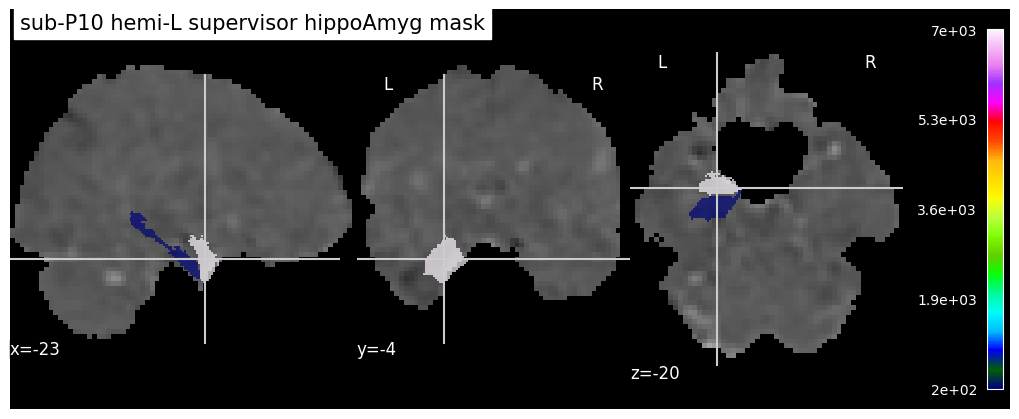

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P10_hemi-L_supervisor_hippoamyg_mask_qc.png


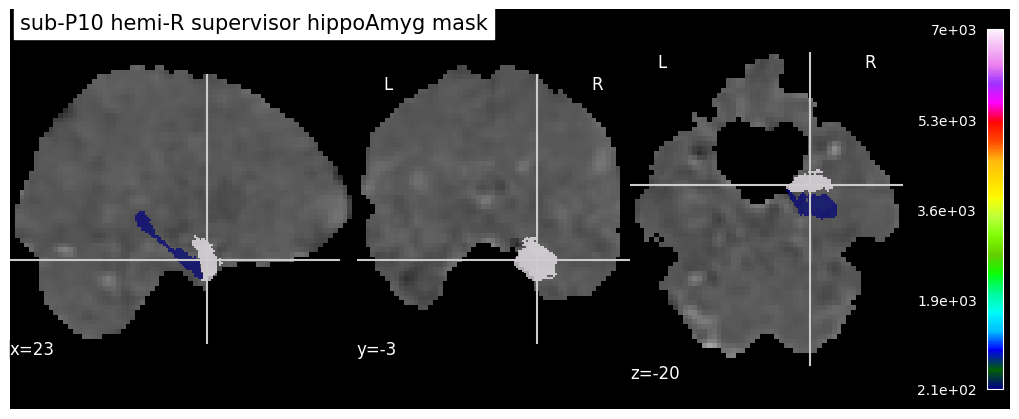

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P10_hemi-R_supervisor_hippoamyg_mask_qc.png


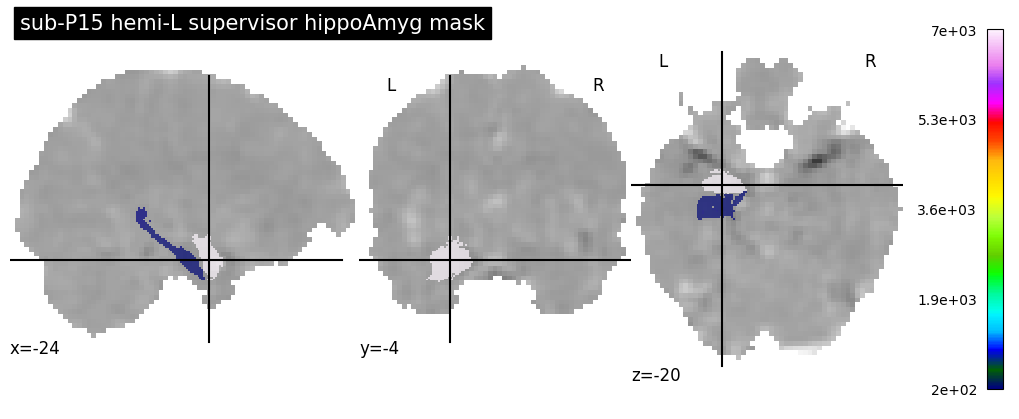

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P15_hemi-L_supervisor_hippoamyg_mask_qc.png


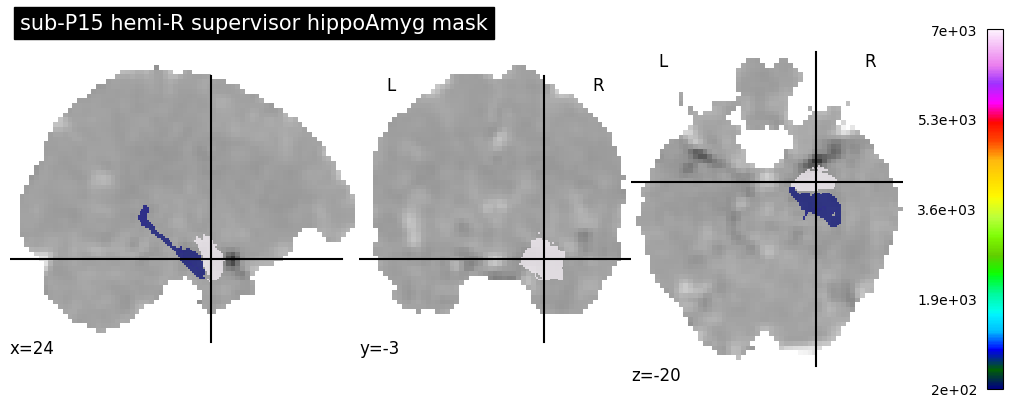

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P15_hemi-R_supervisor_hippoamyg_mask_qc.png


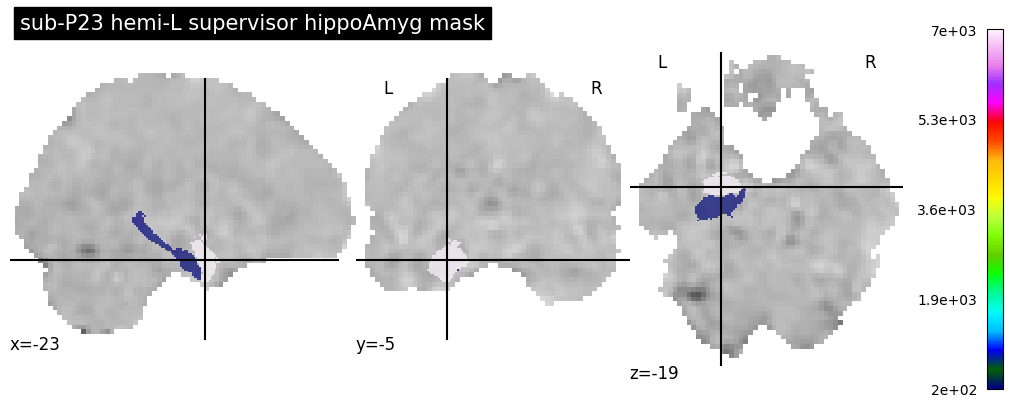

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P23_hemi-L_supervisor_hippoamyg_mask_qc.png


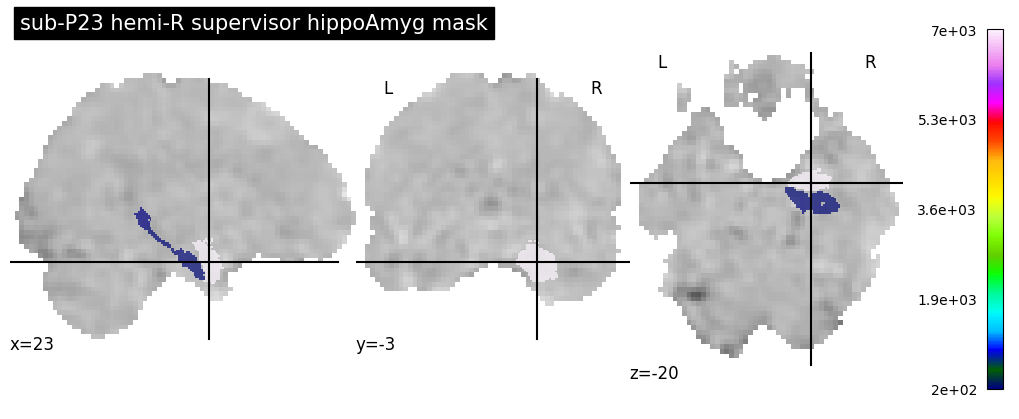

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P23_hemi-R_supervisor_hippoamyg_mask_qc.png


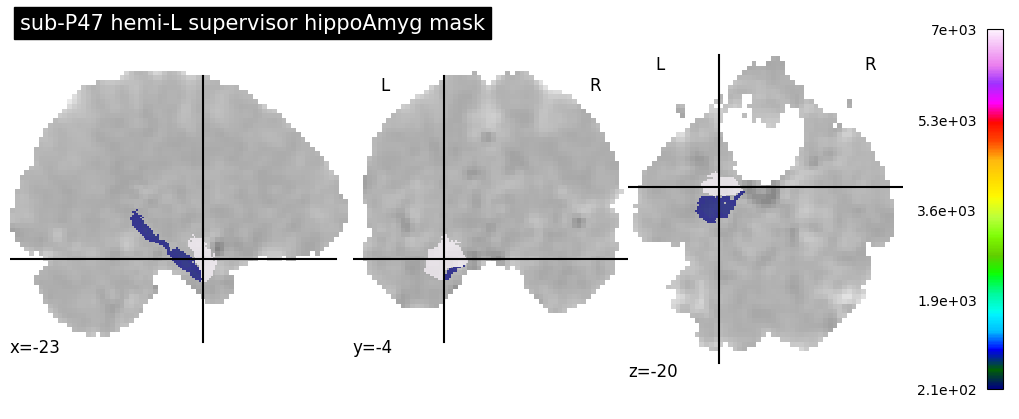

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P47_hemi-L_supervisor_hippoamyg_mask_qc.png


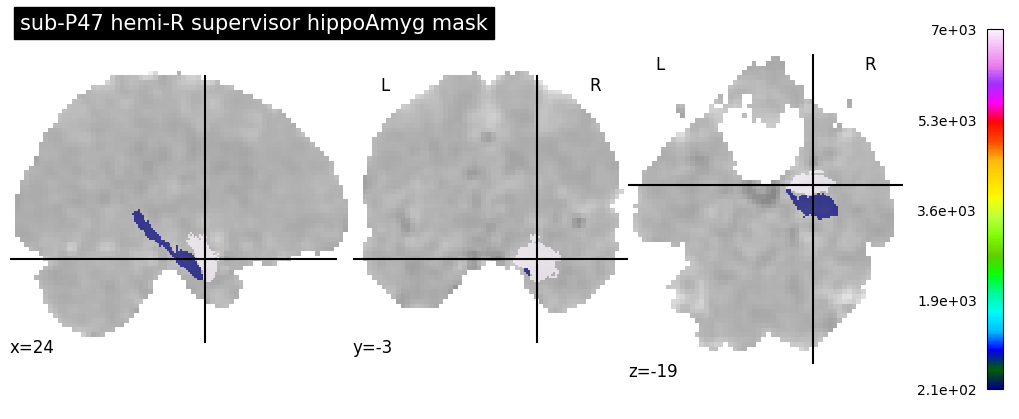

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P47_hemi-R_supervisor_hippoamyg_mask_qc.png


In [19]:
# ============================================================
# S. Visual QC of supervisor masks for selected subjects
# ============================================================

from nilearn.plotting import plot_roi

selected_subjects_mask_qc = [
    "sub-P10",
    "sub-P15",
    "sub-P23",
    "sub-P47",
]

for subject in selected_subjects_mask_qc:
    if subject not in primary_subjects_final:
        continue
    
    reference_effect_path = get_smoothed_first_level_effect_map(
        subject,
        "all_memory_quality_positive",
    )
    reference_img = nib.load(str(reference_effect_path))
    
    for hemi in ["L", "R"]:
        mask_path = get_supervisor_hippoamyg_mask(subject, hemi)
        mask_img = nib.load(str(mask_path))
        
        fig = plt.figure(figsize=(10, 4))
        
        stat_display = plot_roi(
            mask_img,
            bg_img=reference_img,
            display_mode="ortho",
            cut_coords=None,
            title=f"{subject} hemi-{hemi} supervisor hippoAmyg mask",
            figure=fig,
        )
        
        out_path = ROI_FIG_DIR / f"{subject}_hemi-{hemi}_supervisor_hippoamyg_mask_qc.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        
        print("Saved:", out_path)

In [20]:
# ============================================================
# T. Extract ROI effects using supervisor-provided hippoAmyg masks
# ============================================================

from nilearn.image import resample_to_img
from nilearn.masking import apply_mask

supervisor_roi_rows = []

for subject in primary_subjects_final:
    for contrast_name in PRIMARY_CONTRASTS.keys():
        effect_map_path = get_smoothed_first_level_effect_map(subject, contrast_name)
        
        assert effect_map_path.exists(), f"Missing effect map: {effect_map_path}"
        
        effect_img = nib.load(str(effect_map_path))
        hemi_values = {}
        
        for hemi in ["L", "R"]:
            mask_path = get_supervisor_hippoamyg_mask(subject, hemi)
            mask_img = nib.load(str(mask_path))
            
            # Resample mask to effect-map grid if needed.
            if (
                mask_img.shape[:3] != effect_img.shape[:3]
                or not np.allclose(mask_img.affine, effect_img.affine)
            ):
                mask_img = resample_to_img(
                    source_img=mask_img,
                    target_img=effect_img,
                    interpolation="nearest",
                    force_resample=True,
                    copy_header=True,
                )
            
            # Binarize mask.
            mask_data = mask_img.get_fdata() > 0
            
            mask_img_binary = nib.Nifti1Image(
                mask_data.astype(np.uint8),
                affine=effect_img.affine,
                header=effect_img.header,
            )
            
            values = apply_mask(effect_img, mask_img_binary)
            values = values[np.isfinite(values)]
            
            hemi_values[hemi] = values
            
            roi_name = (
                "left_supervisor_hippoamyg"
                if hemi == "L"
                else "right_supervisor_hippoamyg"
            )
            
            supervisor_roi_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "roi": roi_name,
                "hemi": hemi,
                "n_voxels": len(values),
                "mean_effect": float(np.mean(values)),
                "median_effect": float(np.median(values)),
                "std_effect": float(np.std(values, ddof=1)),
                "effect_map_path": str(effect_map_path),
                "mask_path": str(mask_path),
                "first_level_smoothing": "5mm",
                "mask_source": "supervisor_subject_specific_hippoAmyg",
            })
        
        # Bilateral ROI = concatenate left and right voxel values.
        bilateral_values = np.concatenate([hemi_values["L"], hemi_values["R"]])
        
        supervisor_roi_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "roi": "bilateral_supervisor_hippoamyg",
            "hemi": "bilateral",
            "n_voxels": len(bilateral_values),
            "mean_effect": float(np.mean(bilateral_values)),
            "median_effect": float(np.median(bilateral_values)),
            "std_effect": float(np.std(bilateral_values, ddof=1)),
            "effect_map_path": str(effect_map_path),
            "mask_path": (
                str(get_supervisor_hippoamyg_mask(subject, "L"))
                + ";"
                + str(get_supervisor_hippoamyg_mask(subject, "R"))
            ),
            "first_level_smoothing": "5mm",
            "mask_source": "supervisor_subject_specific_hippoAmyg",
        })

supervisor_hippoamyg_roi_effects = pd.DataFrame(supervisor_roi_rows)

print("Supervisor hippoAmyg ROI extraction complete")
print("=" * 80)
print("Rows:", len(supervisor_hippoamyg_roi_effects))
print("Subjects:", supervisor_hippoamyg_roi_effects["subject"].nunique())
print("Contrasts:", supervisor_hippoamyg_roi_effects["contrast"].nunique())
print("ROIs:", supervisor_hippoamyg_roi_effects["roi"].nunique())

display(supervisor_hippoamyg_roi_effects.head())

print("\nVoxel counts by ROI:")
display(
    supervisor_hippoamyg_roi_effects
    .groupby("roi")
    .agg(
        min_voxels=("n_voxels", "min"),
        max_voxels=("n_voxels", "max"),
        mean_voxels=("n_voxels", "mean"),
        sd_voxels=("n_voxels", "std"),
    )
    .reset_index()
)

supervisor_roi_effects_path = ROI_TABLE_DIR / "supervisor_hippoamyg_roi_first_level_effects_smoothed5mm.csv"
supervisor_hippoamyg_roi_effects.to_csv(supervisor_roi_effects_path, index=False)

print("\nSaved:")
print(supervisor_roi_effects_path)

Supervisor hippoAmyg ROI extraction complete
Rows: 336
Subjects: 28
Contrasts: 4
ROIs: 3


,subject,contrast,roi,hemi,n_voxels,mean_effect,median_effect,std_effect,effect_map_path,mask_path,first_level_smoothing,mask_source
0,sub-P10,all_memory_quality_positive,left_supervisor_hippoamyg,L,448,-0.011289,-0.007340,0.079360,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,5mm,supervisor_subject_specific_hippoAmyg
1,sub-P10,all_memory_quality_positive,right_supervisor_hippoamyg,R,451,-0.002302,0.000000,0.068744,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,5mm,supervisor_subject_specific_hippoAmyg
2,sub-P10,all_memory_quality_positive,bilateral_supervisor_hippoamyg,bilateral,899,-0.006781,-0.001134,0.074319,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,5mm,supervisor_subject_specific_hippoAmyg
3,sub-P10,relevant_memory_quality_positive,left_supervisor_hippoamyg,L,448,-0.016146,-0.015809,0.069723,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,5mm,supervisor_subject_specific_hippoAmyg
4,sub-P10,relevant_memory_quality_positive,right_supervisor_hippoamyg,R,451,-0.020560,-0.015072,0.086297,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,5mm,supervisor_subject_specific_hippoAmyg



Voxel counts by ROI:


,roi,min_voxels,max_voxels,mean_voxels,sd_voxels
0,bilateral_supervisor_hippoamyg,859,1020,932.428571,37.656990
1,left_supervisor_hippoamyg,411,494,455.785714,19.923018
2,right_supervisor_hippoamyg,446,526,476.642857,21.225880



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/tables/supervisor_hippoamyg_roi_first_level_effects_smoothed5mm.csv


In [21]:
# ============================================================
# U. One-sample tests for supervisor hippoAmyg ROI effects
# ============================================================

from scipy import stats

supervisor_roi_test_rows = []

for contrast_name in PRIMARY_CONTRASTS.keys():
    for roi_name in [
        "left_supervisor_hippoamyg",
        "right_supervisor_hippoamyg",
        "bilateral_supervisor_hippoamyg",
    ]:
        df = supervisor_hippoamyg_roi_effects.loc[
            (supervisor_hippoamyg_roi_effects["contrast"] == contrast_name)
            & (supervisor_hippoamyg_roi_effects["roi"] == roi_name)
        ].copy()
        
        values = df["mean_effect"].dropna().values
        
        t_stat, p_two_sided = stats.ttest_1samp(values, popmean=0.0)
        
        if t_stat >= 0:
            p_one_sided_positive = p_two_sided / 2
        else:
            p_one_sided_positive = 1 - (p_two_sided / 2)
        
        mean_effect = np.mean(values)
        sd_effect = np.std(values, ddof=1)
        sem_effect = sd_effect / np.sqrt(len(values))
        cohens_dz = mean_effect / sd_effect
        
        ci_low, ci_high = stats.t.interval(
            confidence=0.95,
            df=len(values) - 1,
            loc=mean_effect,
            scale=sem_effect,
        )
        
        supervisor_roi_test_rows.append({
            "contrast": contrast_name,
            "roi": roi_name,
            "n_subjects": len(values),
            "mean_effect": mean_effect,
            "sd_effect": sd_effect,
            "sem_effect": sem_effect,
            "t_stat": t_stat,
            "p_two_sided": p_two_sided,
            "p_one_sided_positive": p_one_sided_positive,
            "cohens_dz": cohens_dz,
            "ci_low_95": ci_low,
            "ci_high_95": ci_high,
            "first_level_smoothing": "5mm",
            "mask_source": "supervisor_subject_specific_hippoAmyg",
        })

supervisor_hippoamyg_roi_tests = pd.DataFrame(supervisor_roi_test_rows)

print("Supervisor hippoAmyg ROI one-sample tests:")
display(
    supervisor_hippoamyg_roi_tests.sort_values(
        ["contrast", "roi"]
    )
)

supervisor_roi_tests_path = ROI_TABLE_DIR / "supervisor_hippoamyg_roi_one_sample_tests_smoothed5mm.csv"
supervisor_hippoamyg_roi_tests.to_csv(supervisor_roi_tests_path, index=False)

print("\nSaved:")
print(supervisor_roi_tests_path)

Supervisor hippoAmyg ROI one-sample tests:


,contrast,roi,n_subjects,mean_effect,sd_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,cohens_dz,ci_low_95,ci_high_95,first_level_smoothing,mask_source
2,all_memory_quality_positive,bilateral_supervisor_hippoamyg,28,-0.005786,0.039028,0.007376,-0.784440,0.439611,0.780195,-0.148245,-0.020919,0.009348,5mm,supervisor_subject_specific_hippoAmyg
0,all_memory_quality_positive,left_supervisor_hippoamyg,28,-0.007596,0.041537,0.007850,-0.967645,0.341810,0.829095,-0.182868,-0.023702,0.008511,5mm,supervisor_subject_specific_hippoAmyg
1,all_memory_quality_positive,right_supervisor_hippoamyg,28,-0.004055,0.039614,0.007486,-0.541704,0.592465,0.703767,-0.102372,-0.019416,0.011305,5mm,supervisor_subject_specific_hippoAmyg
8,irrelevant_memory_quality_positive,bilateral_supervisor_hippoamyg,28,-0.003968,0.057748,0.010913,-0.363544,0.719030,0.640485,-0.068703,-0.026360,0.018425,5mm,supervisor_subject_specific_hippoAmyg
6,irrelevant_memory_quality_positive,left_supervisor_hippoamyg,28,-0.007249,0.062129,0.011741,-0.617420,0.542130,0.728935,-0.116681,-0.031340,0.016842,5mm,supervisor_subject_specific_hippoAmyg
7,irrelevant_memory_quality_positive,right_supervisor_hippoamyg,28,-0.000751,0.060335,0.011402,-0.065907,0.947938,0.526031,-0.012455,-0.024147,0.022644,5mm,supervisor_subject_specific_hippoAmyg
11,relevant_gt_irrelevant_memory_quality,bilateral_supervisor_hippoamyg,28,-0.003636,0.062132,0.011742,-0.309688,0.759176,0.620412,-0.058525,-0.027729,0.020456,5mm,supervisor_subject_specific_hippoAmyg
9,relevant_gt_irrelevant_memory_quality,left_supervisor_hippoamyg,28,-0.000693,0.070352,0.013295,-0.052124,0.958814,0.520593,-0.009850,-0.027973,0.026587,5mm,supervisor_subject_specific_hippoAmyg
10,relevant_gt_irrelevant_memory_quality,right_supervisor_hippoamyg,28,-0.006608,0.062893,0.011886,-0.555939,0.582831,0.708585,-0.105063,-0.030995,0.017780,5mm,supervisor_subject_specific_hippoAmyg
5,relevant_memory_quality_positive,bilateral_supervisor_hippoamyg,28,-0.007604,0.040518,0.007657,-0.993043,0.329506,0.835247,-0.187667,-0.023315,0.008107,5mm,supervisor_subject_specific_hippoAmyg



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/tables/supervisor_hippoamyg_roi_one_sample_tests_smoothed5mm.csv


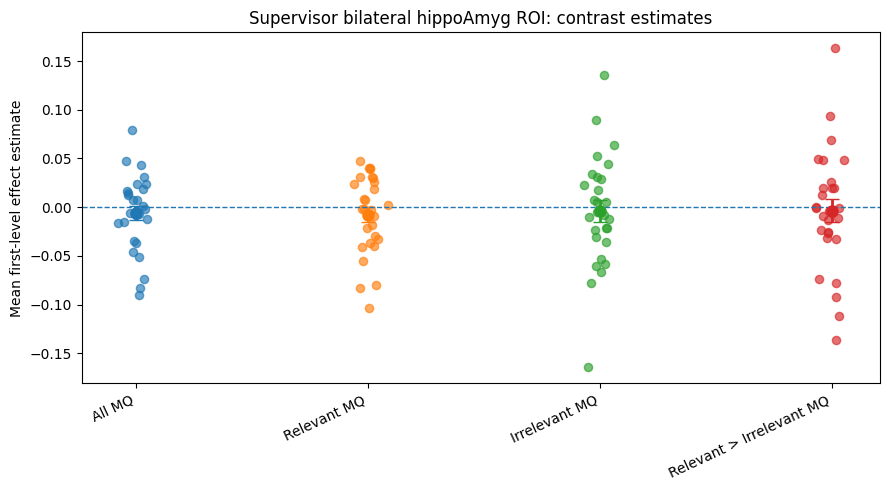

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/supervisor_bilateral_hippoamyg_contrast_effects_smoothed5mm.png


In [22]:
# ============================================================
# V. Plot supervisor bilateral hippoAmyg ROI effects
# ============================================================

plot_roi_name = "bilateral_supervisor_hippoamyg"

plot_df = supervisor_hippoamyg_roi_effects.loc[
    supervisor_hippoamyg_roi_effects["roi"] == plot_roi_name
].copy()

contrast_order = [
    "all_memory_quality_positive",
    "relevant_memory_quality_positive",
    "irrelevant_memory_quality_positive",
    "relevant_gt_irrelevant_memory_quality",
]

contrast_labels = {
    "all_memory_quality_positive": "All MQ",
    "relevant_memory_quality_positive": "Relevant MQ",
    "irrelevant_memory_quality_positive": "Irrelevant MQ",
    "relevant_gt_irrelevant_memory_quality": "Relevant > Irrelevant MQ",
}

fig, ax = plt.subplots(figsize=(9, 5))

x_positions = np.arange(len(contrast_order))
rng = np.random.default_rng(42)

for i, contrast_name in enumerate(contrast_order):
    values = plot_df.loc[
        plot_df["contrast"] == contrast_name,
        "mean_effect",
    ].values
    
    jitter = rng.normal(loc=0, scale=0.04, size=len(values))
    
    ax.scatter(
        np.full(len(values), x_positions[i]) + jitter,
        values,
        alpha=0.65,
        s=35,
    )
    
    mean_val = np.mean(values)
    sem_val = np.std(values, ddof=1) / np.sqrt(len(values))
    
    ax.errorbar(
        x_positions[i],
        mean_val,
        yerr=sem_val,
        marker="o",
        markersize=8,
        capsize=5,
        linewidth=2,
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x_positions)
ax.set_xticklabels([contrast_labels[c] for c in contrast_order], rotation=25, ha="right")
ax.set_ylabel("Mean first-level effect estimate")
ax.set_title("Supervisor bilateral hippoAmyg ROI: contrast estimates")
plt.tight_layout()

supervisor_roi_plot_path = ROI_FIG_DIR / "supervisor_bilateral_hippoamyg_contrast_effects_smoothed5mm.png"
fig.savefig(supervisor_roi_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", supervisor_roi_plot_path)

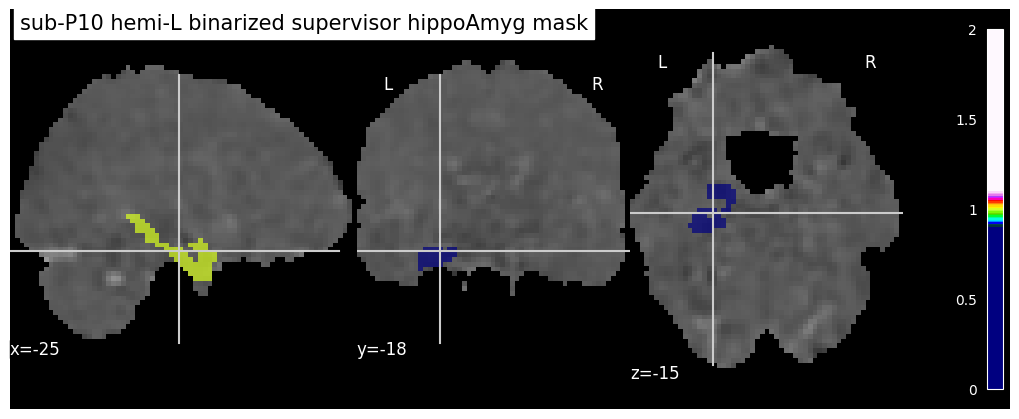

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P10_hemi-L_supervisor_hippoamyg_binary_resampled_mask_qc.png


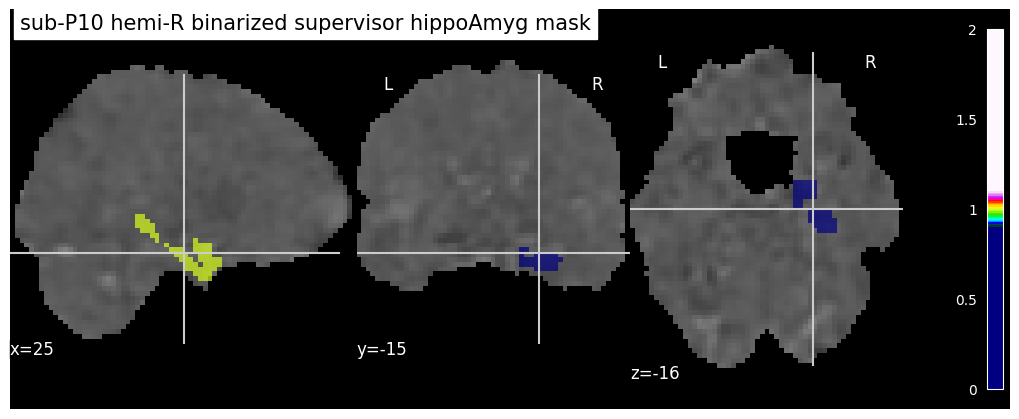

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P10_hemi-R_supervisor_hippoamyg_binary_resampled_mask_qc.png


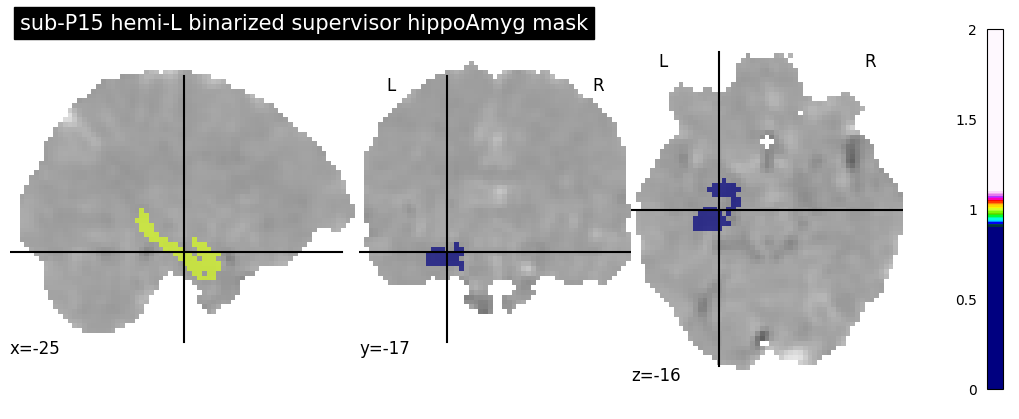

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P15_hemi-L_supervisor_hippoamyg_binary_resampled_mask_qc.png


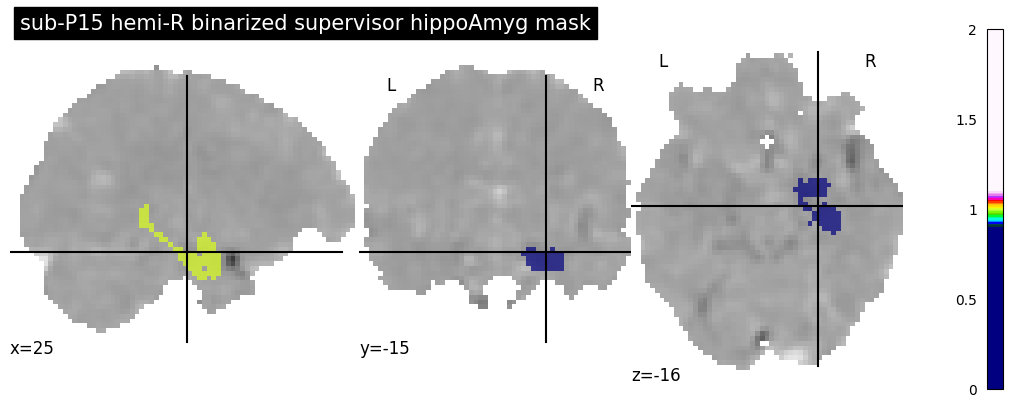

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P15_hemi-R_supervisor_hippoamyg_binary_resampled_mask_qc.png


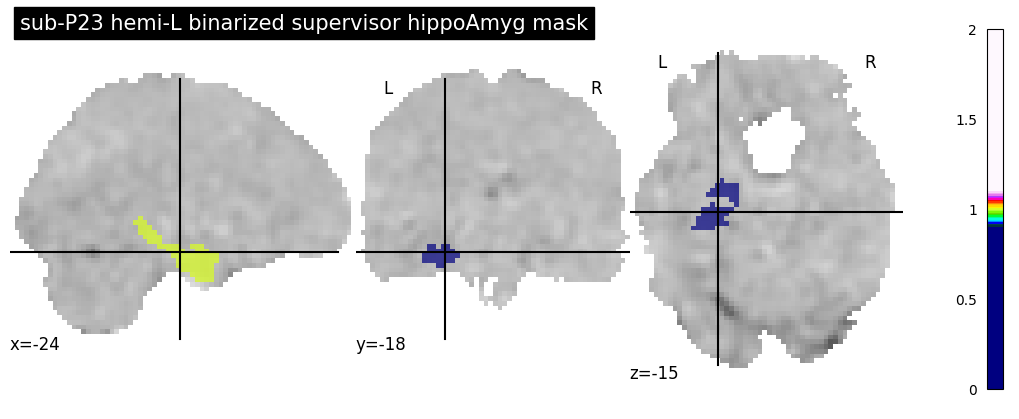

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P23_hemi-L_supervisor_hippoamyg_binary_resampled_mask_qc.png


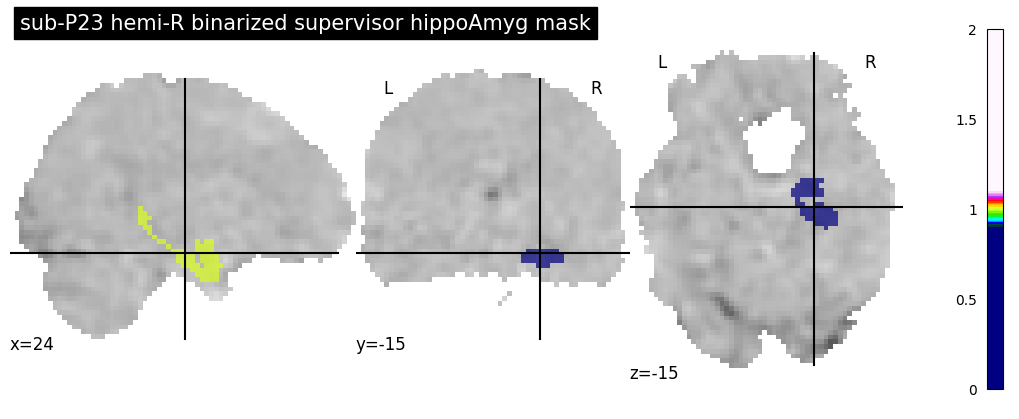

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P23_hemi-R_supervisor_hippoamyg_binary_resampled_mask_qc.png


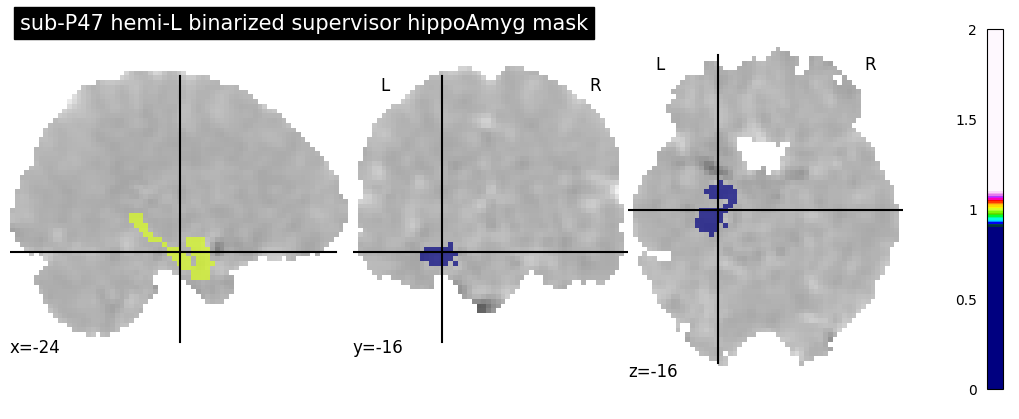

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P47_hemi-L_supervisor_hippoamyg_binary_resampled_mask_qc.png


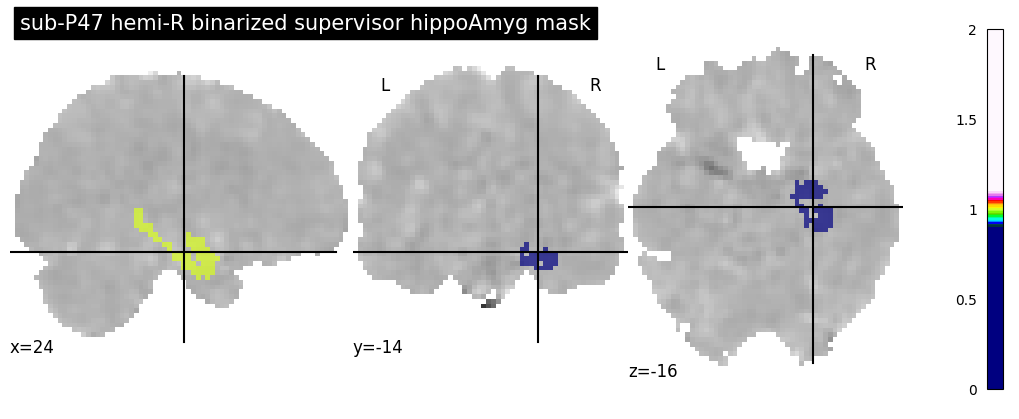

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/sub-P47_hemi-R_supervisor_hippoamyg_binary_resampled_mask_qc.png


In [23]:
# ============================================================
# W. Cleaner visual QC: binarized and resampled supervisor masks
# ============================================================

from nilearn.image import resample_to_img, new_img_like
from nilearn.plotting import plot_roi

selected_subjects_mask_qc = [
    "sub-P10",
    "sub-P15",
    "sub-P23",
    "sub-P47",
]

for subject in selected_subjects_mask_qc:
    if subject not in primary_subjects_final:
        continue
    
    reference_effect_path = get_smoothed_first_level_effect_map(
        subject,
        "all_memory_quality_positive",
    )
    reference_img = nib.load(str(reference_effect_path))
    
    for hemi in ["L", "R"]:
        mask_path = get_supervisor_hippoamyg_mask(subject, hemi)
        mask_img = nib.load(str(mask_path))
        
        # Resample to GLM grid if needed
        if (
            mask_img.shape[:3] != reference_img.shape[:3]
            or not np.allclose(mask_img.affine, reference_img.affine)
        ):
            mask_img = resample_to_img(
                source_img=mask_img,
                target_img=reference_img,
                interpolation="nearest",
                force_resample=True,
                copy_header=True,
            )
        
        # Binarize for visualization
        mask_binary_data = (mask_img.get_fdata() > 0).astype(np.uint8)
        mask_binary_img = new_img_like(reference_img, mask_binary_data)
        
        fig = plt.figure(figsize=(10, 4))
        
        stat_display = plot_roi(
            mask_binary_img,
            bg_img=reference_img,
            display_mode="ortho",
            cut_coords=None,
            title=f"{subject} hemi-{hemi} binarized supervisor hippoAmyg mask",
            figure=fig,
        )
        
        out_path = ROI_FIG_DIR / f"{subject}_hemi-{hemi}_supervisor_hippoamyg_binary_resampled_mask_qc.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        
        print("Saved:", out_path)

In [24]:
# ============================================================
# X. Compact summary of ROI results across ROI definitions
# ============================================================

hipp_tests_summary = hippocampus_roi_tests.copy()
hipp_tests_summary["roi_family"] = "Harvard-Oxford hippocampus"
hipp_tests_summary["mask_source"] = "Harvard-Oxford"
hipp_tests_summary["first_level_smoothing"] = "5mm"

mtl_tests_summary = mtl_roi_tests.copy()
mtl_tests_summary["roi_family"] = "Harvard-Oxford hippocampus+amygdala"
mtl_tests_summary["mask_source"] = "Harvard-Oxford"
mtl_tests_summary["first_level_smoothing"] = "5mm"

supervisor_tests_summary = supervisor_hippoamyg_roi_tests.copy()
supervisor_tests_summary["roi_family"] = "Supervisor subject-specific hippoAmyg"
supervisor_tests_summary["mask_source"] = "Supervisor masks"
supervisor_tests_summary["first_level_smoothing"] = "5mm"

all_roi_tests_summary = pd.concat(
    [
        hipp_tests_summary,
        mtl_tests_summary,
        supervisor_tests_summary,
    ],
    ignore_index=True,
)

compact_roi_summary = all_roi_tests_summary[
    [
        "roi_family",
        "contrast",
        "roi",
        "n_subjects",
        "mean_effect",
        "t_stat",
        "p_two_sided",
        "p_one_sided_positive",
        "cohens_dz",
        "ci_low_95",
        "ci_high_95",
        "first_level_smoothing",
    ]
].sort_values(["contrast", "roi_family", "roi"])

display(compact_roi_summary)

compact_roi_summary_path = ROI_TABLE_DIR / "compact_roi_summary_all_definitions_smoothed5mm.csv"
compact_roi_summary.to_csv(compact_roi_summary_path, index=False)

print("Saved:")
print(compact_roi_summary_path)

,roi_family,contrast,roi,n_subjects,mean_effect,t_stat,p_two_sided,p_one_sided_positive,cohens_dz,ci_low_95,ci_high_95,first_level_smoothing
2,Harvard-Oxford hippocampus,all_memory_quality_positive,bilateral_hippocampus,28,-0.003372,-0.447336,0.658201,0.670900,-0.084539,-0.018841,0.012096,5mm
0,Harvard-Oxford hippocampus,all_memory_quality_positive,left_hippocampus,28,-0.005890,-0.672356,0.507071,0.746465,-0.127063,-0.023865,0.012085,5mm
1,Harvard-Oxford hippocampus,all_memory_quality_positive,right_hippocampus,28,-0.000898,-0.126294,0.900435,0.549782,-0.023867,-0.015483,0.013687,5mm
14,Harvard-Oxford hippocampus+amygdala,all_memory_quality_positive,bilateral_mtl_hippocampus_amygdala,28,-0.006867,-0.815240,0.422068,0.788966,-0.154066,-0.024149,0.010416,5mm
12,Harvard-Oxford hippocampus+amygdala,all_memory_quality_positive,left_mtl_hippocampus_amygdala,28,-0.009003,-0.938268,0.356425,0.821788,-0.177316,-0.028690,0.010685,5mm
13,Harvard-Oxford hippocampus+amygdala,all_memory_quality_positive,right_mtl_hippocampus_amygdala,28,-0.004811,-0.603664,0.551105,0.724447,-0.114082,-0.021164,0.011542,5mm
26,Supervisor subject-specific hippoAmyg,all_memory_quality_positive,bilateral_supervisor_hippoamyg,28,-0.005786,-0.784440,0.439611,0.780195,-0.148245,-0.020919,0.009348,5mm
24,Supervisor subject-specific hippoAmyg,all_memory_quality_positive,left_supervisor_hippoamyg,28,-0.007596,-0.967645,0.341810,0.829095,-0.182868,-0.023702,0.008511,5mm
25,Supervisor subject-specific hippoAmyg,all_memory_quality_positive,right_supervisor_hippoamyg,28,-0.004055,-0.541704,0.592465,0.703767,-0.102372,-0.019416,0.011305,5mm
8,Harvard-Oxford hippocampus,irrelevant_memory_quality_positive,bilateral_hippocampus,28,0.000905,0.080187,0.936680,0.468340,0.015154,-0.022263,0.024073,5mm


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/tables/compact_roi_summary_all_definitions_smoothed5mm.csv


### Subject-specific supervisor hippoAmyg ROI

In addition to atlas-defined Harvard-Oxford ROIs, we used supervisor-provided participant-specific hippocampus/amygdala masks. For each participant, left and right masks in MNI152NLin2009cAsym space were resampled to the first-level GLM effect-map grid using nearest-neighbor interpolation and binarized before extraction. Bilateral ROI values were computed by concatenating left and right ROI voxels.

The supervisor masks were available for all 28 primary-analysis participants. After resampling to the GLM grid, the bilateral ROI contained on average approximately 932 voxels.

Consistent with the Harvard-Oxford ROI analyses, the supervisor-defined hippoAmyg ROI did not show evidence for positive memory-quality modulation. The all-memory-quality, relevant-memory-quality, irrelevant-memory-quality, and relevant-greater-than-irrelevant interaction contrasts were all centered near zero or slightly negative in the bilateral ROI.

Together, these ROI analyses suggest that the exploratory whole-brain memory-quality effects are not driven by a robust hippocampal or medial temporal lobe effect in the current GLM.

In [25]:
# ============================================================
# W. Check unsmoothed first-level maps for ROI sensitivity
# ============================================================

FIRST_LEVEL_UNSMOOTHED_DIR = OUT_DIR / "first_level"
FIRST_LEVEL_UNSMOOTHED_MAPS_DIR = FIRST_LEVEL_UNSMOOTHED_DIR / "maps"

def get_unsmoothed_first_level_effect_map(subject, contrast_name):
    return (
        FIRST_LEVEL_UNSMOOTHED_MAPS_DIR
        / f"{subject}_{contrast_name}_effect.nii.gz"
    )

def get_unsmoothed_first_level_z_map(subject, contrast_name):
    return (
        FIRST_LEVEL_UNSMOOTHED_MAPS_DIR
        / f"{subject}_{contrast_name}_zmap.nii.gz"
    )

unsmoothed_check_rows = []

for subject in primary_subjects_final:
    for contrast_name in PRIMARY_CONTRASTS.keys():
        effect_path = get_unsmoothed_first_level_effect_map(subject, contrast_name)
        z_path = get_unsmoothed_first_level_z_map(subject, contrast_name)
        
        unsmoothed_check_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "effect_exists": effect_path.exists(),
            "z_exists": z_path.exists(),
            "effect_path": str(effect_path),
            "z_path": str(z_path),
        })

unsmoothed_map_check = pd.DataFrame(unsmoothed_check_rows)

print("Unsmoothed first-level map availability:")
display(
    unsmoothed_map_check
    .groupby("contrast")
    .agg(
        n_subjects=("subject", "count"),
        n_effect_maps=("effect_exists", "sum"),
        n_z_maps=("z_exists", "sum"),
    )
    .reset_index()
)

missing_unsmoothed_maps = unsmoothed_map_check.loc[
    (~unsmoothed_map_check["effect_exists"])
    | (~unsmoothed_map_check["z_exists"])
].copy()

print("\nMissing unsmoothed maps:")
display(missing_unsmoothed_maps)

assert missing_unsmoothed_maps.empty, "Some unsmoothed first-level maps are missing."

unsmoothed_map_check_path = ROI_TABLE_DIR / "unsmoothed_first_level_map_availability_for_roi.csv"
unsmoothed_map_check.to_csv(unsmoothed_map_check_path, index=False)

print("\nSaved:")
print(unsmoothed_map_check_path)

Unsmoothed first-level map availability:


,contrast,n_subjects,n_effect_maps,n_z_maps
0,all_memory_quality_positive,28,28,28
1,irrelevant_memory_quality_positive,28,28,28
2,relevant_gt_irrelevant_memory_quality,28,28,28
3,relevant_memory_quality_positive,28,28,28



Missing unsmoothed maps:


,subject,contrast,effect_exists,z_exists,effect_path,z_path



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/tables/unsmoothed_first_level_map_availability_for_roi.csv


In [26]:
# ============================================================
# X. Extract unsmoothed ROI effects using supervisor hippoAmyg masks
# ============================================================

from nilearn.image import resample_to_img
from nilearn.masking import apply_mask

supervisor_roi_unsmoothed_rows = []

for subject in primary_subjects_final:
    for contrast_name in PRIMARY_CONTRASTS.keys():
        effect_map_path = get_unsmoothed_first_level_effect_map(subject, contrast_name)
        
        assert effect_map_path.exists(), f"Missing effect map: {effect_map_path}"
        
        effect_img = nib.load(str(effect_map_path))
        hemi_values = {}
        
        for hemi in ["L", "R"]:
            mask_path = get_supervisor_hippoamyg_mask(subject, hemi)
            mask_img = nib.load(str(mask_path))
            
            # Resample subject-specific mask to unsmoothed effect-map grid if needed.
            if (
                mask_img.shape[:3] != effect_img.shape[:3]
                or not np.allclose(mask_img.affine, effect_img.affine)
            ):
                mask_img = resample_to_img(
                    source_img=mask_img,
                    target_img=effect_img,
                    interpolation="nearest",
                    force_resample=True,
                    copy_header=True,
                )
            
            # Binarize.
            mask_data = mask_img.get_fdata() > 0
            
            mask_img_binary = nib.Nifti1Image(
                mask_data.astype(np.uint8),
                affine=effect_img.affine,
                header=effect_img.header,
            )
            
            values = apply_mask(effect_img, mask_img_binary)
            values = values[np.isfinite(values)]
            
            hemi_values[hemi] = values
            
            roi_name = (
                "left_supervisor_hippoamyg"
                if hemi == "L"
                else "right_supervisor_hippoamyg"
            )
            
            supervisor_roi_unsmoothed_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "roi": roi_name,
                "hemi": hemi,
                "n_voxels": len(values),
                "mean_effect": float(np.mean(values)),
                "median_effect": float(np.median(values)),
                "std_effect": float(np.std(values, ddof=1)),
                "effect_map_path": str(effect_map_path),
                "mask_path": str(mask_path),
                "first_level_smoothing": "none",
                "mask_source": "supervisor_subject_specific_hippoAmyg",
            })
        
        bilateral_values = np.concatenate([hemi_values["L"], hemi_values["R"]])
        
        supervisor_roi_unsmoothed_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "roi": "bilateral_supervisor_hippoamyg",
            "hemi": "bilateral",
            "n_voxels": len(bilateral_values),
            "mean_effect": float(np.mean(bilateral_values)),
            "median_effect": float(np.median(bilateral_values)),
            "std_effect": float(np.std(bilateral_values, ddof=1)),
            "effect_map_path": str(effect_map_path),
            "mask_path": (
                str(get_supervisor_hippoamyg_mask(subject, "L"))
                + ";"
                + str(get_supervisor_hippoamyg_mask(subject, "R"))
            ),
            "first_level_smoothing": "none",
            "mask_source": "supervisor_subject_specific_hippoAmyg",
        })

supervisor_hippoamyg_roi_effects_unsmoothed = pd.DataFrame(
    supervisor_roi_unsmoothed_rows
)

print("Unsmoothed supervisor hippoAmyg ROI extraction complete")
print("=" * 80)
print("Rows:", len(supervisor_hippoamyg_roi_effects_unsmoothed))
print("Subjects:", supervisor_hippoamyg_roi_effects_unsmoothed["subject"].nunique())
print("Contrasts:", supervisor_hippoamyg_roi_effects_unsmoothed["contrast"].nunique())
print("ROIs:", supervisor_hippoamyg_roi_effects_unsmoothed["roi"].nunique())

display(supervisor_hippoamyg_roi_effects_unsmoothed.head())

print("\nVoxel counts by ROI:")
display(
    supervisor_hippoamyg_roi_effects_unsmoothed
    .groupby("roi")
    .agg(
        min_voxels=("n_voxels", "min"),
        max_voxels=("n_voxels", "max"),
        mean_voxels=("n_voxels", "mean"),
        sd_voxels=("n_voxels", "std"),
    )
    .reset_index()
)

supervisor_roi_unsmoothed_effects_path = (
    ROI_TABLE_DIR / "supervisor_hippoamyg_roi_first_level_effects_unsmoothed.csv"
)
supervisor_hippoamyg_roi_effects_unsmoothed.to_csv(
    supervisor_roi_unsmoothed_effects_path,
    index=False,
)

print("\nSaved:")
print(supervisor_roi_unsmoothed_effects_path)

Unsmoothed supervisor hippoAmyg ROI extraction complete
Rows: 336
Subjects: 28
Contrasts: 4
ROIs: 3


,subject,contrast,roi,hemi,n_voxels,mean_effect,median_effect,std_effect,effect_map_path,mask_path,first_level_smoothing,mask_source
0,sub-P10,all_memory_quality_positive,left_supervisor_hippoamyg,L,448,-0.019807,-0.021764,0.216462,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,none,supervisor_subject_specific_hippoAmyg
1,sub-P10,all_memory_quality_positive,right_supervisor_hippoamyg,R,451,-0.004978,-0.006037,0.221857,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,none,supervisor_subject_specific_hippoAmyg
2,sub-P10,all_memory_quality_positive,bilateral_supervisor_hippoamyg,bilateral,899,-0.012368,-0.014594,0.219188,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,none,supervisor_subject_specific_hippoAmyg
3,sub-P10,relevant_memory_quality_positive,left_supervisor_hippoamyg,L,448,-0.018574,0.000000,0.236716,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,none,supervisor_subject_specific_hippoAmyg
4,sub-P10,relevant_memory_quality_positive,right_supervisor_hippoamyg,R,451,-0.033349,-0.024809,0.321558,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,none,supervisor_subject_specific_hippoAmyg



Voxel counts by ROI:


,roi,min_voxels,max_voxels,mean_voxels,sd_voxels
0,bilateral_supervisor_hippoamyg,859,1020,932.428571,37.656990
1,left_supervisor_hippoamyg,411,494,455.785714,19.923018
2,right_supervisor_hippoamyg,446,526,476.642857,21.225880



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/tables/supervisor_hippoamyg_roi_first_level_effects_unsmoothed.csv


In [27]:
# ============================================================
# Y. One-sample tests for unsmoothed supervisor hippoAmyg ROI
# ============================================================

from scipy import stats

supervisor_roi_unsmoothed_test_rows = []

for contrast_name in PRIMARY_CONTRASTS.keys():
    for roi_name in [
        "left_supervisor_hippoamyg",
        "right_supervisor_hippoamyg",
        "bilateral_supervisor_hippoamyg",
    ]:
        df = supervisor_hippoamyg_roi_effects_unsmoothed.loc[
            (supervisor_hippoamyg_roi_effects_unsmoothed["contrast"] == contrast_name)
            & (supervisor_hippoamyg_roi_effects_unsmoothed["roi"] == roi_name)
        ].copy()
        
        values = df["mean_effect"].dropna().values
        
        t_stat, p_two_sided = stats.ttest_1samp(values, popmean=0.0)
        
        if t_stat >= 0:
            p_one_sided_positive = p_two_sided / 2
        else:
            p_one_sided_positive = 1 - (p_two_sided / 2)
        
        mean_effect = np.mean(values)
        sd_effect = np.std(values, ddof=1)
        sem_effect = sd_effect / np.sqrt(len(values))
        cohens_dz = mean_effect / sd_effect
        
        ci_low, ci_high = stats.t.interval(
            confidence=0.95,
            df=len(values) - 1,
            loc=mean_effect,
            scale=sem_effect,
        )
        
        supervisor_roi_unsmoothed_test_rows.append({
            "contrast": contrast_name,
            "roi": roi_name,
            "n_subjects": len(values),
            "mean_effect": mean_effect,
            "sd_effect": sd_effect,
            "sem_effect": sem_effect,
            "t_stat": t_stat,
            "p_two_sided": p_two_sided,
            "p_one_sided_positive": p_one_sided_positive,
            "cohens_dz": cohens_dz,
            "ci_low_95": ci_low,
            "ci_high_95": ci_high,
            "first_level_smoothing": "none",
            "mask_source": "supervisor_subject_specific_hippoAmyg",
        })

supervisor_hippoamyg_roi_tests_unsmoothed = pd.DataFrame(
    supervisor_roi_unsmoothed_test_rows
)

print("Unsmoothed supervisor hippoAmyg ROI one-sample tests:")
display(
    supervisor_hippoamyg_roi_tests_unsmoothed.sort_values(
        ["contrast", "roi"]
    )
)

supervisor_roi_unsmoothed_tests_path = (
    ROI_TABLE_DIR / "supervisor_hippoamyg_roi_one_sample_tests_unsmoothed.csv"
)
supervisor_hippoamyg_roi_tests_unsmoothed.to_csv(
    supervisor_roi_unsmoothed_tests_path,
    index=False,
)

print("\nSaved:")
print(supervisor_roi_unsmoothed_tests_path)

Unsmoothed supervisor hippoAmyg ROI one-sample tests:


,contrast,roi,n_subjects,mean_effect,sd_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,cohens_dz,ci_low_95,ci_high_95,first_level_smoothing,mask_source
2,all_memory_quality_positive,bilateral_supervisor_hippoamyg,28,-0.006386,0.042626,0.008055,-0.792703,0.434862,0.782569,-0.149807,-0.022914,0.010143,none,supervisor_subject_specific_hippoAmyg
0,all_memory_quality_positive,left_supervisor_hippoamyg,28,-0.008286,0.044648,0.008438,-0.982085,0.334777,0.832612,-0.185597,-0.025599,0.009026,none,supervisor_subject_specific_hippoAmyg
1,all_memory_quality_positive,right_supervisor_hippoamyg,28,-0.004525,0.044061,0.008327,-0.543458,0.591274,0.704363,-0.102704,-0.021610,0.012560,none,supervisor_subject_specific_hippoAmyg
8,irrelevant_memory_quality_positive,bilateral_supervisor_hippoamyg,28,-0.004558,0.062719,0.011853,-0.384548,0.703585,0.648208,-0.072673,-0.028878,0.019762,none,supervisor_subject_specific_hippoAmyg
6,irrelevant_memory_quality_positive,left_supervisor_hippoamyg,28,-0.005715,0.063962,0.012088,-0.472756,0.640187,0.679907,-0.089342,-0.030517,0.019087,none,supervisor_subject_specific_hippoAmyg
7,irrelevant_memory_quality_positive,right_supervisor_hippoamyg,28,-0.003327,0.068745,0.012992,-0.256123,0.799797,0.600101,-0.048403,-0.029984,0.023329,none,supervisor_subject_specific_hippoAmyg
11,relevant_gt_irrelevant_memory_quality,bilateral_supervisor_hippoamyg,28,-0.003655,0.066440,0.012556,-0.291115,0.773188,0.613406,-0.055015,-0.029418,0.022108,none,supervisor_subject_specific_hippoAmyg
9,relevant_gt_irrelevant_memory_quality,left_supervisor_hippoamyg,28,-0.005144,0.070607,0.013343,-0.385493,0.702893,0.648554,-0.072851,-0.032522,0.022235,none,supervisor_subject_specific_hippoAmyg
10,relevant_gt_irrelevant_memory_quality,right_supervisor_hippoamyg,28,-0.002396,0.072593,0.013719,-0.174621,0.862680,0.568660,-0.033000,-0.030544,0.025753,none,supervisor_subject_specific_hippoAmyg
5,relevant_memory_quality_positive,bilateral_supervisor_hippoamyg,28,-0.008213,0.043673,0.008253,-0.995130,0.328509,0.835746,-0.188062,-0.025148,0.008721,none,supervisor_subject_specific_hippoAmyg



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/tables/supervisor_hippoamyg_roi_one_sample_tests_unsmoothed.csv


In [28]:
# ============================================================
# Z. Compare 5 mm smoothed vs unsmoothed supervisor ROI tests
# ============================================================

supervisor_smoothed_tests_for_comparison = supervisor_hippoamyg_roi_tests.copy()
supervisor_smoothed_tests_for_comparison["first_level_smoothing"] = "5mm"

supervisor_unsmoothed_tests_for_comparison = supervisor_hippoamyg_roi_tests_unsmoothed.copy()
supervisor_unsmoothed_tests_for_comparison["first_level_smoothing"] = "none"

supervisor_smoothing_comparison = pd.concat(
    [
        supervisor_smoothed_tests_for_comparison,
        supervisor_unsmoothed_tests_for_comparison,
    ],
    ignore_index=True,
)

supervisor_smoothing_comparison = supervisor_smoothing_comparison[
    [
        "first_level_smoothing",
        "contrast",
        "roi",
        "n_subjects",
        "mean_effect",
        "t_stat",
        "p_two_sided",
        "p_one_sided_positive",
        "cohens_dz",
        "ci_low_95",
        "ci_high_95",
        "mask_source",
    ]
].sort_values(["contrast", "roi", "first_level_smoothing"])

display(supervisor_smoothing_comparison)

supervisor_smoothing_comparison_path = (
    ROI_TABLE_DIR / "supervisor_hippoamyg_roi_smoothed5mm_vs_unsmoothed.csv"
)
supervisor_smoothing_comparison.to_csv(
    supervisor_smoothing_comparison_path,
    index=False,
)

print("Saved:")
print(supervisor_smoothing_comparison_path)

,first_level_smoothing,contrast,roi,n_subjects,mean_effect,t_stat,p_two_sided,p_one_sided_positive,cohens_dz,ci_low_95,ci_high_95,mask_source
2,5mm,all_memory_quality_positive,bilateral_supervisor_hippoamyg,28,-0.005786,-0.784440,0.439611,0.780195,-0.148245,-0.020919,0.009348,supervisor_subject_specific_hippoAmyg
14,none,all_memory_quality_positive,bilateral_supervisor_hippoamyg,28,-0.006386,-0.792703,0.434862,0.782569,-0.149807,-0.022914,0.010143,supervisor_subject_specific_hippoAmyg
0,5mm,all_memory_quality_positive,left_supervisor_hippoamyg,28,-0.007596,-0.967645,0.341810,0.829095,-0.182868,-0.023702,0.008511,supervisor_subject_specific_hippoAmyg
12,none,all_memory_quality_positive,left_supervisor_hippoamyg,28,-0.008286,-0.982085,0.334777,0.832612,-0.185597,-0.025599,0.009026,supervisor_subject_specific_hippoAmyg
1,5mm,all_memory_quality_positive,right_supervisor_hippoamyg,28,-0.004055,-0.541704,0.592465,0.703767,-0.102372,-0.019416,0.011305,supervisor_subject_specific_hippoAmyg
13,none,all_memory_quality_positive,right_supervisor_hippoamyg,28,-0.004525,-0.543458,0.591274,0.704363,-0.102704,-0.021610,0.012560,supervisor_subject_specific_hippoAmyg
8,5mm,irrelevant_memory_quality_positive,bilateral_supervisor_hippoamyg,28,-0.003968,-0.363544,0.719030,0.640485,-0.068703,-0.026360,0.018425,supervisor_subject_specific_hippoAmyg
20,none,irrelevant_memory_quality_positive,bilateral_supervisor_hippoamyg,28,-0.004558,-0.384548,0.703585,0.648208,-0.072673,-0.028878,0.019762,supervisor_subject_specific_hippoAmyg
6,5mm,irrelevant_memory_quality_positive,left_supervisor_hippoamyg,28,-0.007249,-0.617420,0.542130,0.728935,-0.116681,-0.031340,0.016842,supervisor_subject_specific_hippoAmyg
18,none,irrelevant_memory_quality_positive,left_supervisor_hippoamyg,28,-0.005715,-0.472756,0.640187,0.679907,-0.089342,-0.030517,0.019087,supervisor_subject_specific_hippoAmyg


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/tables/supervisor_hippoamyg_roi_smoothed5mm_vs_unsmoothed.csv


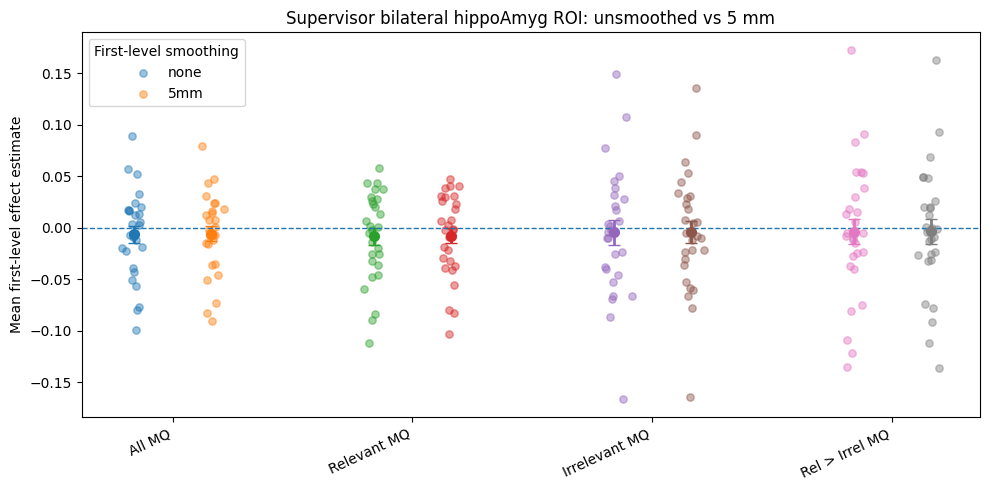

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/roi/figures/supervisor_bilateral_hippoamyg_unsmoothed_vs_smoothed5mm.png


In [29]:
# ============================================================
# AA. Plot bilateral supervisor ROI: smoothed vs unsmoothed
# ============================================================

plot_roi_name = "bilateral_supervisor_hippoamyg"

smoothed_plot_df = supervisor_hippoamyg_roi_effects.loc[
    supervisor_hippoamyg_roi_effects["roi"] == plot_roi_name
].copy()
smoothed_plot_df["first_level_smoothing"] = "5mm"

unsmoothed_plot_df = supervisor_hippoamyg_roi_effects_unsmoothed.loc[
    supervisor_hippoamyg_roi_effects_unsmoothed["roi"] == plot_roi_name
].copy()
unsmoothed_plot_df["first_level_smoothing"] = "none"

plot_df = pd.concat(
    [smoothed_plot_df, unsmoothed_plot_df],
    ignore_index=True,
)

contrast_order = [
    "all_memory_quality_positive",
    "relevant_memory_quality_positive",
    "irrelevant_memory_quality_positive",
    "relevant_gt_irrelevant_memory_quality",
]

contrast_labels = {
    "all_memory_quality_positive": "All MQ",
    "relevant_memory_quality_positive": "Relevant MQ",
    "irrelevant_memory_quality_positive": "Irrelevant MQ",
    "relevant_gt_irrelevant_memory_quality": "Rel > Irrel MQ",
}

smoothing_order = ["none", "5mm"]
offsets = {"none": -0.16, "5mm": 0.16}

fig, ax = plt.subplots(figsize=(10, 5))

rng = np.random.default_rng(42)
x_positions = np.arange(len(contrast_order))

for i, contrast_name in enumerate(contrast_order):
    for smoothing in smoothing_order:
        values = plot_df.loc[
            (plot_df["contrast"] == contrast_name)
            & (plot_df["first_level_smoothing"] == smoothing),
            "mean_effect",
        ].values
        
        x_center = x_positions[i] + offsets[smoothing]
        jitter = rng.normal(loc=0, scale=0.025, size=len(values))
        
        ax.scatter(
            np.full(len(values), x_center) + jitter,
            values,
            alpha=0.45,
            s=28,
            label=smoothing if i == 0 else None,
        )
        
        mean_val = np.mean(values)
        sem_val = np.std(values, ddof=1) / np.sqrt(len(values))
        
        ax.errorbar(
            x_center,
            mean_val,
            yerr=sem_val,
            marker="o",
            markersize=7,
            capsize=4,
            linewidth=2,
        )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x_positions)
ax.set_xticklabels([contrast_labels[c] for c in contrast_order], rotation=25, ha="right")
ax.set_ylabel("Mean first-level effect estimate")
ax.set_title("Supervisor bilateral hippoAmyg ROI: unsmoothed vs 5 mm")
ax.legend(title="First-level smoothing")
plt.tight_layout()

supervisor_smoothing_plot_path = (
    ROI_FIG_DIR / "supervisor_bilateral_hippoamyg_unsmoothed_vs_smoothed5mm.png"
)
fig.savefig(supervisor_smoothing_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", supervisor_smoothing_plot_path)

### Smoothing sensitivity for supervisor hippoAmyg ROI

Because the medial temporal lobe is a relatively small anatomical region, we repeated the supervisor-defined hippoAmyg ROI extraction using unsmoothed first-level effect maps. This tested whether the null ROI result from the 5 mm smoothed first-level maps could have been caused by spatial smoothing.

The unsmoothed ROI results closely matched the 5 mm smoothed results. For the bilateral supervisor-defined hippoAmyg ROI, all primary contrasts remained centered near zero or slightly negative. The all-memory-quality contrast, relevant-memory-quality contrast, irrelevant-memory-quality contrast, and relevant-greater-than-irrelevant interaction all failed to show evidence for a positive ROI effect.

Thus, the absence of positive hippoAmyg memory-quality modulation was robust to the first-level smoothing convention.